In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
sales = pd.read_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_sales_capstone 1\data\raw\salesdata.csv")
customers = pd.read_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_sales_capstone 1\data\raw\customers.csv")
products = pd.read_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_sales_capstone 1\data\raw\products.csv")
stores = pd.read_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_sales_capstone 1\data\raw\stores.csv")
returns = pd.read_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_sales_capstone 1\data\raw\returns.csv")

customers .csv

In [3]:
customers.head()

,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18.0,11-07-2025,South
1,C0001,Eric,Lee,Other,36.0,20-09-2021,East
2,C0002,Thomas,Pena,Female,NaN,07-03-2022,East
3,C0003,Dalton,Duran,Male,24.0,29-08-2022,South
4,C0004,Travis,Mcclain,Male,50.0,29-03-2024,South


In [4]:
customers.tail()

,customer_id,first_name,last_name,gender,age,signup_date,region
811,C0476,John,Le,Female,29.0,23-11-2023,West
812,C0059,Alison,Berger,Male,56.0,16-11-2021,West
813,C0600,Timothy,Cunningham,Male,39.0,24-04-2022,South
814,C0480,Matthew,Moore,Female,27.0,23-05-2021,South
815,C0515,Elizabeth,Alvarez,Other,46.0,22-07-2024,East


In [5]:
customers.describe()

,age
count,776.000000
mean,44.074742
std,15.316349
min,18.000000
25%,31.000000
50%,44.000000
75%,58.000000
max,70.000000


In [6]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  816 non-null    object 
 1   first_name   816 non-null    object 
 2   last_name    816 non-null    object 
 3   gender       816 non-null    object 
 4   age          776 non-null    float64
 5   signup_date  816 non-null    object 
 6   region       816 non-null    object 
dtypes: float64(1), object(6)
memory usage: 44.8+ KB


In [8]:
#check for duplicate values
print('no.of duplicates:',customers.duplicated().sum())

no.of duplicates: 16


In [242]:
# Remove duplicate rows
customers = customers.drop_duplicates()


In [243]:
#check for duplicate values
print('no.of duplicates:',customers.duplicated().sum())

no.of duplicates: 0


In [244]:
customers.isnull().sum()

customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

In [245]:
# Fill missing age with median
customers['age'] = customers['age'].fillna(customers['age'].median())

In [246]:
# Convert signup_date to datetime
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')

In [247]:
# Create Age Group column
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[0,18,25,35,45,60,100],
    labels=['0-18','19-25','26-35','36-45','46-60','60+']
)

In [248]:
customers.isnull().sum()

customer_id      0
first_name       0
last_name        0
gender           0
age              0
signup_date    499
region           0
age_group        0
dtype: int64

In [249]:
# Compare original column before conversion
print(customers.loc[customers['signup_date'].isna(), 'signup_date'])

1     NaT
3     NaT
4     NaT
5     NaT
8     NaT
       ..
790   NaT
792   NaT
793   NaT
794   NaT
797   NaT
Name: signup_date, Length: 499, dtype: datetime64[ns]


In [250]:
median_date = customers['signup_date'].dropna().median()
customers['signup_date'] = customers['signup_date'].fillna(median_date)

In [251]:
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
age_group      0
dtype: int64

In [252]:
#change date type
customers = customers.astype({
    "customer_id": "string",
    "first_name": "string",
    "last_name": "string",
    "gender": "string",
    "region": "string"
})

customers["age"] = pd.to_numeric(customers["age"], errors="coerce").astype("Int64")



In [253]:
#check data type
customers.dtypes

customer_id    string[python]
first_name     string[python]
last_name      string[python]
gender         string[python]
age                     Int64
signup_date    datetime64[ns]
region         string[python]
age_group            category
dtype: object

In [254]:
customers.isnull().sum()

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
age_group      0
dtype: int64

In [255]:
#save csv file
customers.to_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_Sales_Capstone 1\data\cleaned\customers_cleaned.csv")
customers

,customer_id,first_name,last_name,gender,age,signup_date,region,age_group
0,C0000,Patrick,Morgan,Male,18,2025-11-07,South,0-18
1,C0001,Eric,Lee,Other,36,2023-11-11,East,36-45
2,C0002,Thomas,Pena,Female,44,2022-07-03,East,36-45
3,C0003,Dalton,Duran,Male,24,2023-11-11,South,19-25
4,C0004,Travis,Mcclain,Male,50,2023-11-11,South,46-60
...,...,...,...,...,...,...,...,...
795,C0795,Emily,Smith,Male,42,2025-03-04,South,36-45
796,C0796,Jonathan,Gardner,Other,20,2024-08-03,South,19-25
797,C0797,Jordan,Smith,Other,56,2023-11-11,West,46-60
798,C0798,Rachel,Porter,Other,39,2021-12-08,South,36-45


Products .csv

In [3]:
#check top rows
products.head()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


In [4]:
# display last few rows
products.tail()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
1219,P0998,BrandB Stuff,Personal Care,BrandD,13.87,19.62,29.31
1220,P0684,BrandA Hear,Home & Kitchen,BrandC,161.31,222.84,27.61
1221,P0498,BrandD South,Personal Care,BrandD,19.73,35.81,44.90
1222,P1016,BrandA Watch,Electronics,BrandC,186.81,321.00,41.80
1223,P0188,BrandA Strong,Apparel,BrandB,172.73,302.59,42.92


In [5]:
products.describe()

,cost_price,unit_price,margin_pct
count,1224.000000,1224.000000,1224.000000
mean,103.030016,159.559428,33.869158
std,55.981671,90.679397,11.267576
min,5.290000,6.770000,9.120000
25%,54.697500,83.887500,25.397500
50%,104.490000,157.590000,36.260000
75%,151.342500,226.220000,43.135000
max,199.470000,382.320000,49.990000


In [9]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1224 non-null   object 
 1   product_name  1224 non-null   object 
 2   category      1224 non-null   object 
 3   brand         1164 non-null   object 
 4   cost_price    1224 non-null   float64
 5   unit_price    1224 non-null   float64
 6   margin_pct    1224 non-null   float64
dtypes: float64(3), object(4)
memory usage: 67.1+ KB


In [6]:
#check duplicate values
print('no of duplicaes',products.duplicated().sum())

no of duplicaes 24


In [7]:
#drop duplicates
products = products.drop_duplicates()

In [8]:
#check duplicate values
print('no of duplicaes',products.duplicated().sum())

no of duplicaes 0


In [9]:
# check null values
products.isnull().sum()

product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64

In [10]:
#fill unknown
products['brand'] = products['brand'].fillna('unbranded')

In [11]:
# check null values
products.isnull().sum()

product_id      0
product_name    0
category        0
brand           0
cost_price      0
unit_price      0
margin_pct      0
dtype: int64

In [12]:
#check data type
products.dtypes

product_id       object
product_name     object
category         object
brand            object
cost_price      float64
unit_price      float64
margin_pct      float64
dtype: object

In [13]:
products = products.astype({
    "product_id": "string",
    "product_name": "string",
    "category": "string",
    "brand": "string",
    "cost_price": "float",
    "unit_price": "float",
    "margin_pct": "float"
})

In [14]:
#check data type
products.dtypes

product_id      string[python]
product_name    string[python]
category        string[python]
brand           string[python]
cost_price             float64
unit_price             float64
margin_pct             float64
dtype: object

In [15]:
# check null values
products.isnull().sum()

product_id      0
product_name    0
category        0
brand           0
cost_price      0
unit_price      0
margin_pct      0
dtype: int64

In [16]:
#check duplicate values
print('no of duplicaes',products.duplicated().sum())

no of duplicaes 0


In [17]:
#save csv file
products.to_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_Sales_Capstone 1\data\cleaned\products_cleaned.csv")
products


,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35
...,...,...,...,...,...,...,...
1195,P1195,BrandB Challenge,Home & Kitchen,BrandB,15.31,21.82,29.84
1196,P1196,BrandC Better,Electronics,BrandC,61.87,103.64,40.30
1197,P1197,BrandA Own,Apparel,BrandB,154.11,252.57,38.98
1198,P1198,BrandB Your,Home & Kitchen,BrandC,166.23,285.33,41.74


sales .csv

In [28]:
#check top rows
sales.head()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
0,O00000,31-01-2025,C0125,P1086,NaN,Online,2,80.63,0.05,153.20
1,O00001,29-09-2025,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00
2,O00002,29-08-2024,C0653,P0659,NaN,Online,2,218.60,0.10,393.48
3,O00003,13-05-2025,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82
4,O00004,22-07-2025,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94


In [29]:
sales.tail()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
3055,O02044,26-09-2025,C0580,P0886,S024,In-Store,2,82.92,0.00,165.84
3056,O02352,16-11-2024,C0632,P0091,S034,In-Store,1,27.29,0.10,24.56
3057,O02014,25-06-2024,C0127,P0296,NaN,Online,3,34.89,0.00,104.67
3058,O01371,12-02-2025,C0741,P1056,NaN,Online,1,57.51,0.05,54.63
3059,O00797,27-03-2025,C0479,P0659,NaN,Online,10,218.60,0.10,1967.40


In [30]:
sales.describe()

,quantity,unit_price,discount_pct,total_amount
count,3060.000000,3060.000000,3060.000000,3060.000000
mean,1.816340,160.494961,0.088056,272.423582
std,1.749869,91.106112,0.074714,411.177912
min,1.000000,6.770000,0.000000,6.970000
25%,1.000000,83.700000,0.050000,107.467500
50%,2.000000,161.170000,0.050000,196.580000
75%,2.000000,229.100000,0.200000,337.460000
max,30.000000,382.320000,0.200000,8855.800000


In [10]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3060 non-null   object 
 1   order_date     3060 non-null   object 
 2   customer_id    3060 non-null   object 
 3   product_id     3060 non-null   object 
 4   store_id       2068 non-null   object 
 5   sales_channel  3060 non-null   object 
 6   quantity       3060 non-null   int64  
 7   unit_price     3060 non-null   float64
 8   discount_pct   3060 non-null   float64
 9   total_amount   3060 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 239.2+ KB


In [31]:
#check duplicates
print('no of duplicates:',sales.duplicated().sum())

no of duplicates: 60


In [32]:
#drop duplicates
sales = sales.drop_duplicates()

In [33]:
#check duplicates
print('no of duplicates:',sales.duplicated().sum())

no of duplicates: 0


In [34]:
print(sales.isnull().sum())

order_id           0
order_date         0
customer_id        0
product_id         0
store_id         968
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64


In [35]:
# Compare original column before conversion
print(sales.loc[sales['store_id'].isna(), 'store_id'])

0       NaN
2       NaN
9       NaN
14      NaN
17      NaN
       ... 
2979    NaN
2987    NaN
2988    NaN
2990    NaN
2995    NaN
Name: store_id, Length: 968, dtype: object


In [36]:

# Convert to numeric safely
sales["store_id"] = pd.to_numeric(sales["store_id"], errors="coerce")

# If all values are NaN, start from 1
if sales["store_id"].notna().any():
    max_id = int(sales["store_id"].max())
else:
    max_id = 0

# Mask missing values
mask = sales["store_id"].isnull()

# Fill missing with sequential numbers
sales.loc[mask, "store_id"] = range(max_id + 1, max_id + 1 + mask.sum())

print("Missing after:", sales["store_id"].isnull().sum())

Missing after: 0


In [37]:
# Compare original column before conversion
print(sales.loc[sales['store_id'].isna(), 'store_id'])

Series([], Name: store_id, dtype: float64)


In [38]:
sales['store_missing_flag'] = sales['store_id'].isna().astype(int)


In [39]:
#fill with unknown
sales['store_id'] = sales["store_id"].fillna("online")

In [40]:
print(sales.isnull().sum())

order_id              0
order_date            0
customer_id           0
product_id            0
store_id              0
sales_channel         0
quantity              0
unit_price            0
discount_pct          0
total_amount          0
store_missing_flag    0
dtype: int64


In [41]:
#changing data type
sales['order_date'] = pd.to_datetime(sales['order_date'],dayfirst=True,errors='coerce')

In [42]:
print(sales.isnull().sum())

order_id              0
order_date            5
customer_id           0
product_id            0
store_id              0
sales_channel         0
quantity              0
unit_price            0
discount_pct          0
total_amount          0
store_missing_flag    0
dtype: int64


In [43]:
median_date = sales['order_date'].median()
sales['order_date'] = sales['order_date'].fillna(median_date)


In [44]:
print(sales.isnull().sum())

order_id              0
order_date            0
customer_id           0
product_id            0
store_id              0
sales_channel         0
quantity              0
unit_price            0
discount_pct          0
total_amount          0
store_missing_flag    0
dtype: int64


In [45]:
#check data types
sales.dtypes

order_id                      object
order_date            datetime64[ns]
customer_id                   object
product_id                    object
store_id                     float64
sales_channel                 object
quantity                       int64
unit_price                   float64
discount_pct                 float64
total_amount                 float64
store_missing_flag             int64
dtype: object

In [46]:
sales = sales.astype({
    "order_id": "string",
    "customer_id": "string",
    "product_id": "string",
    "store_id": "string",
    "sales_channel": "string",
    "quantity": "Int64",       
    "unit_price": "float",
    "discount_pct": "float",
    "total_amount": "float"
})

In [47]:
#check data types
sales.dtypes

order_id              string[python]
order_date            datetime64[ns]
customer_id           string[python]
product_id            string[python]
store_id              string[python]
sales_channel         string[python]
quantity                       Int64
unit_price                   float64
discount_pct                 float64
total_amount                 float64
store_missing_flag             int64
dtype: object

In [48]:
#adding column
sales= sales.merge(products[["product_id", "cost_price"]],on="product_id",how="left")
sales["profit"] = (sales["total_amount"] -(sales["cost_price"] * sales["quantity"]))


In [49]:
print(sales.isnull().sum())

order_id              0
order_date            0
customer_id           0
product_id            0
store_id              0
sales_channel         0
quantity              0
unit_price            0
discount_pct          0
total_amount          0
store_missing_flag    0
cost_price            0
profit                0
dtype: int64


In [50]:
#save csv file
sales.to_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_Sales_Capstone 1\data\cleaned\sales_cleaned.csv")
        

stores.csv

In [51]:
#check top rows
stores.head()

,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26


In [52]:
stores.tail()

,store_id,store_name,store_type,region,city,operating_cost
56,S056,"Johnson, Sims and Miles Store",Mall Kiosk,East,Los Angeles,75869.37
57,S057,"Crawford, Spencer and Lopez Store",Franchise,West,Houston,52756.63
58,S058,Hubbard-Thomas Store,Mall Kiosk,East,New York,10215.93
59,S059,"Foster, Gutierrez and Li Store",Franchise,West,Los Angeles,11797.63
60,S017,Robinson PLC Store,Flagship,East,Phoenix,47603.84


In [53]:
#basic info
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        61 non-null     object 
 1   store_name      61 non-null     object 
 2   store_type      61 non-null     object 
 3   region          61 non-null     object 
 4   city            61 non-null     object 
 5   operating_cost  61 non-null     float64
dtypes: float64(1), object(5)
memory usage: 3.0+ KB


In [54]:
stores.describe()

,operating_cost
count,61.000000
mean,40329.226721
std,19225.845475
min,10215.930000
25%,22350.490000
50%,39178.960000
75%,52756.630000
max,78806.300000


In [55]:
#check null values
stores.isnull().sum()

store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

In [56]:
#check duplicates
print('no of duplicates:',stores.duplicated().sum())

no of duplicates: 1


In [57]:
#drop duplicate values
stores = stores.drop_duplicates()

In [58]:
#check duplicates
print('no of duplicates:',stores.duplicated().sum())

no of duplicates: 0


In [59]:
#check data types
stores.dtypes

store_id           object
store_name         object
store_type         object
region             object
city               object
operating_cost    float64
dtype: object

In [60]:
#check null values
stores.isnull().sum()

store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

In [61]:
#check duplicates
print('no of duplicates:',stores.duplicated().sum())

no of duplicates: 0


In [62]:
#save csv file
stores.to_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_Sales_Capstone 1\data\cleaned\stores_cleaned.csv")


returns.csv

In [159]:
#check top rows
returns.head()

,return_id,order_id,return_date,return_reason
0,R0000,O02237,05-03-2025,Defective
1,R0001,O01700,18-03-2025,Defective
2,R0002,O01451,18-02-2025,Late Delivery
3,R0003,O02759,26-10-2024,Defective
4,R0004,O00415,06-08-2025,No Longer Needed


In [160]:
#check last rows
returns.tail()

,return_id,order_id,return_date,return_reason
199,R0199,O01305,26-01-2025,No Longer Needed
200,R0182,O00585,24-08-2025,Late Delivery
201,R0156,O01596,27-01-2025,No Longer Needed
202,R0194,O00934,09-09-2025,Wrong Item
203,R0035,O02071,10-08-2024,Defective


In [161]:
#basic info
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      204 non-null    object
 1   order_id       204 non-null    object
 2   return_date    204 non-null    object
 3   return_reason  204 non-null    object
dtypes: object(4)
memory usage: 6.5+ KB


In [162]:
#check duplicate values
print('no of duplicates:- ',returns.duplicated().sum())

no of duplicates:-  4


In [163]:
#drop duplicate values
returns = returns.drop_duplicates()

In [164]:
#check duplicate values
print('no of duplicates:- ',returns.duplicated().sum())

no of duplicates:-  0


In [165]:
#check null values
returns.isnull().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [171]:
#change date type
returns.loc[:, 'return_date'] = pd.to_datetime(returns['return_date'],dayfirst=True,errors='coerce')

In [172]:
#check null values
returns.isnull().sum()

return_id        0
order_id         0
return_date      1
return_reason    0
dtype: int64

In [173]:
# Compare original column before conversion
print(returns.loc[returns['return_date'].isna(), 'return_date'])

86    NaT
Name: return_date, dtype: object


In [176]:
returns = returns.dropna(subset=["return_date"])

In [177]:
#check null values
returns.isnull().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [178]:
#check duplicate values
print('no of duplicates:- ',returns.duplicated().sum())

no of duplicates:-  0


In [179]:
#save csv file
returns.to_csv(r"C:\Users\PRANITH\OneDrive\Desktop\Retail_Sales_Capstone 1\data\cleaned\returns_cleaned.csv")

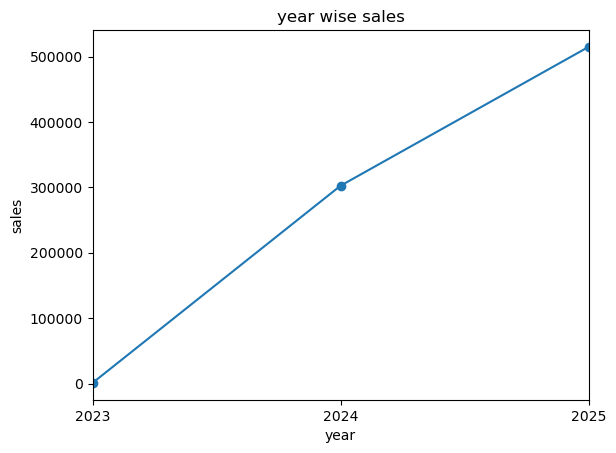

In [293]:
# sales trends year wise
sales['year'] = sales['order_date'].dt.to_period('Y')
year_sales = sales.groupby('year')['total_amount'].sum()
year_sales.plot(kind='line' , marker='o')
plt.title('year wise sales')
plt.xlabel('year')
plt.ylabel('sales')
plt.show()

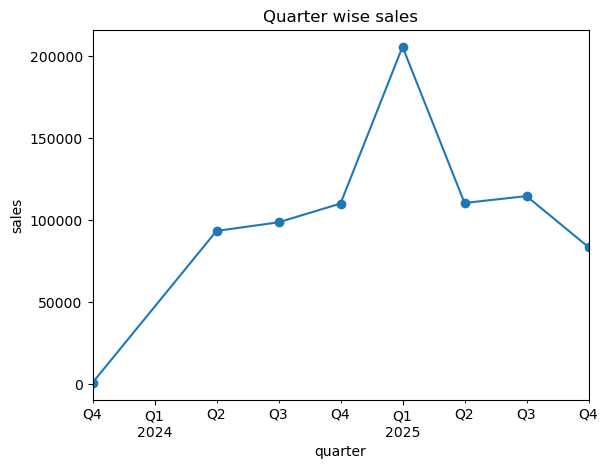

In [294]:
#sales trend quater wise
sales['quarter'] = sales['order_date'].dt.to_period('Q')
quarter_sales= sales.groupby('quarter')['total_amount'].sum()
quarter_sales.plot(kind='line' , marker='o')
plt.title('Quarter wise sales')
plt.xlabel('quarter')
plt.ylabel('sales')
plt.show()

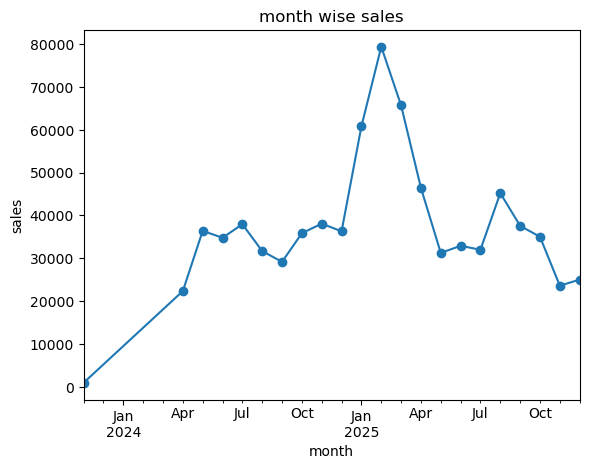

In [295]:
# sales trend month wise
sales['month'] = sales['order_date'].dt.to_period('M')
month_sales= sales.groupby('month')['total_amount'].sum()
month_sales.plot(kind='line', marker='o')
plt.title('month wise sales')
plt.xlabel('month')
plt.ylabel('sales')
plt.show()

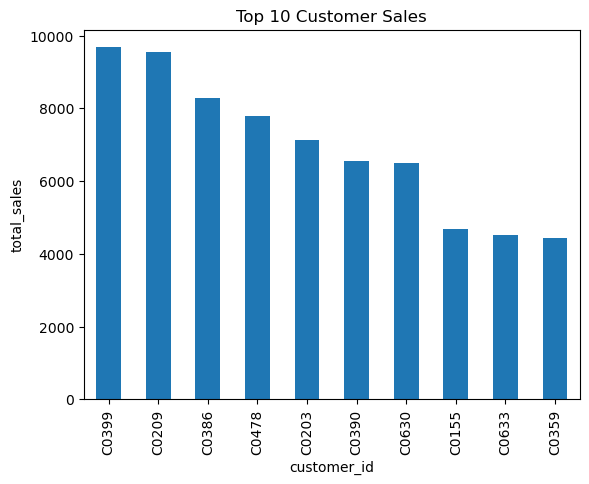

In [296]:
#top 10 customer sales
top_customers = sales.groupby('customer_id')['total_amount'].sum().sort_values(ascending = False).head(10)
top_customers.plot(kind='bar')
plt.title('Top 10 Customer Sales')
plt.ylabel('total_sales')
plt.show()